<a href="https://colab.research.google.com/github/CaduPereira0921/data_science_aula01/blob/main/Live1_EDA_MallCustomers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problema de Análise: Segmentação Estratégica de Clientes

**Contexto:**
A empresa possui dados demográficos e de consumo de sua base de clientes, mas opera com uma abordagem de marketing genérica, o que resulta em baixa eficiência em campanhas e alocação de recursos.

**O Desafio:**
Como identificar padrões comportamentais ocultos que permitam agrupar clientes além da simples demografia?

**Objetivos da Análise:**
1. **Entender a relação** entre Renda Anual e Score de Gastos (identificando se 'quem ganha mais, gasta mais').
2. **Mitigar distorções** estatísticas através do tratamento de outliers.
3. **Gerar insights** para uma futura segmentação (Clustering) que permita a criação de ofertas personalizadas para diferentes perfis de consumo.

**Análise Exploratória de Dados**

O notebook abaixo realiza uma análise exploratória completa do dataset *Mall Customers* (dados de clientes de um shopping: gênero, idade, renda anual e spending score). O objetivo é transformar dados brutos em insights de negócio acionáveis.


**Célula 1 — Instalação e Imports**

In [ ]:
# ============================================================
# Aula 1 — Big Data e Business Analytics
# Análise Exploratória de Dados — Mall Customers Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='Blues_d')
pd.set_option('display.max_columns', None)


**Célula 2 — Carregamento do Dataset**

In [ ]:
# ----- Carregamento via URL pública (sem upload) -----
URL = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
df = pd.read_csv(URL)

# ----- Primeiros passos: conhecer os dados -----
print('Shape (linhas, colunas):', df.shape)
print('\nPrimeiras 5 linhas:')
display(df.head())

print('\nTipos de dados (identificando variáveis):')
display(df.dtypes)

print('\nEstatísticas descritivas básicas:')
display(df.describe())

print('\nValores nulos por coluna:')
display(df.isnull().sum())

Shape (linhas, colunas): (200, 5)

Primeiras 5 linhas:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Tipos de dados (identificando variáveis):


,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64



Estatísticas descritivas básicas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Valores nulos por coluna:


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Célula 3 — Análise de Variáveis Categóricas**

Distribuição por gênero:
Genre
Female    112
Male       88
Name: count, dtype: int64
Genre
Female    56.0
Male      44.0
Name: proportion, dtype: float64


/tmp/ipykernel_1070/3725662310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Genre', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1070/3725662310.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)', ax=axes[1], palette='Blues_d')


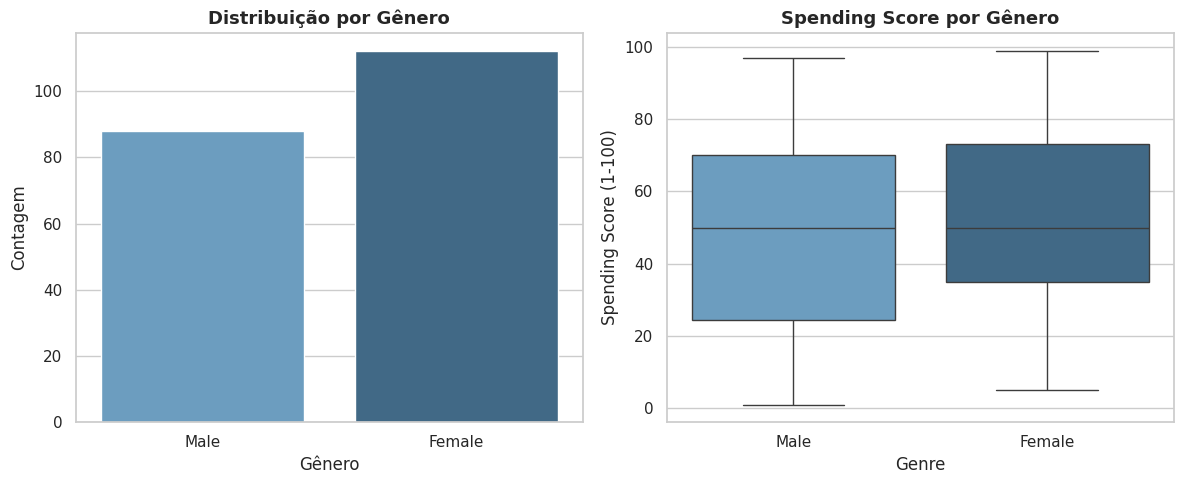


Média de Spending Score por Gênero:
Genre
Female    51.5
Male      48.5
Name: Spending Score (1-100), dtype: float64


In [ ]:
# ----- Análise da variável categórica: Gênero -----
print('Distribuição por gênero:')
print(df['Genre'].value_counts())
print(df['Genre'].value_counts(normalize=True).mul(100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(data=df, x='Genre', ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribuição por Gênero', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gênero'); axes[0].set_ylabel('Contagem')

# Spending Score por Gênero
sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)', ax=axes[1], palette='Blues_d')
axes[1].set_title('Spending Score por Gênero', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# PERGUNTA: O gênero influencia o comportamento de compra?
print('\nMédia de Spending Score por Gênero:')
print(df.groupby('Genre')['Spending Score (1-100)'].mean().round(1))


**Célula 4 — Análise de Variáveis Numéricas**

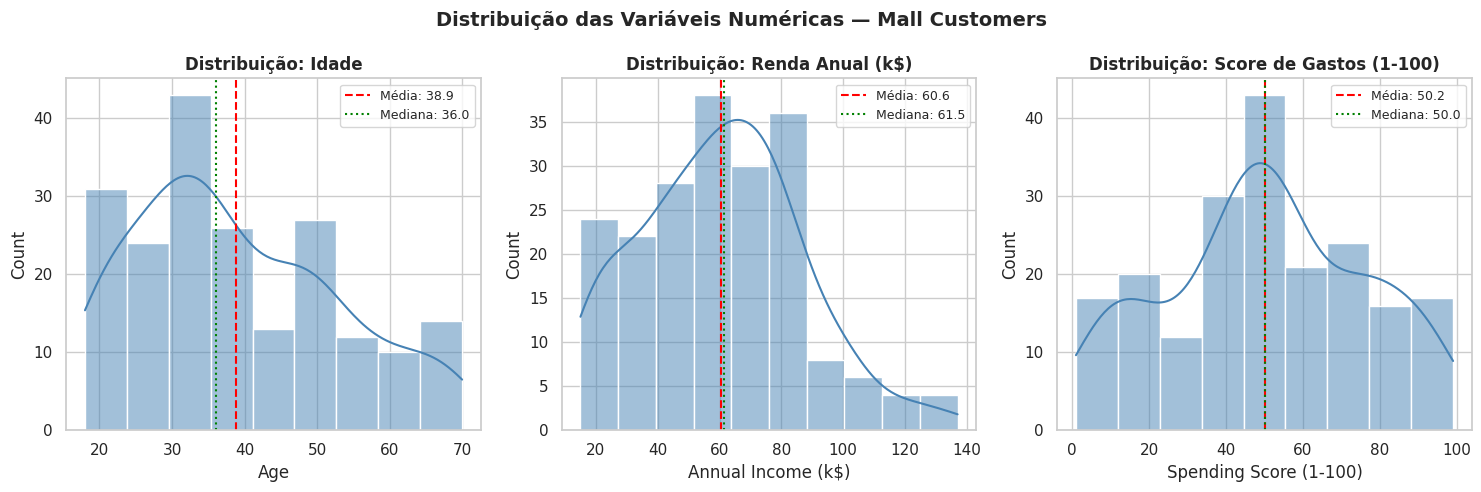

In [ ]:
# ----- Histogramas das variáveis numéricas -----
variaveis_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
nomes_pt = ['Idade', 'Renda Anual (k$)', 'Score de Gastos (1-100)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, nome) in enumerate(zip(variaveis_numericas, nomes_pt)):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribuição: {nome}', fontweight='bold')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Média: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle=':', label=f'Mediana: {df[col].median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das Variáveis Numéricas — Mall Customers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


**Célula 5 — Heatmap de Correlação e Insights**

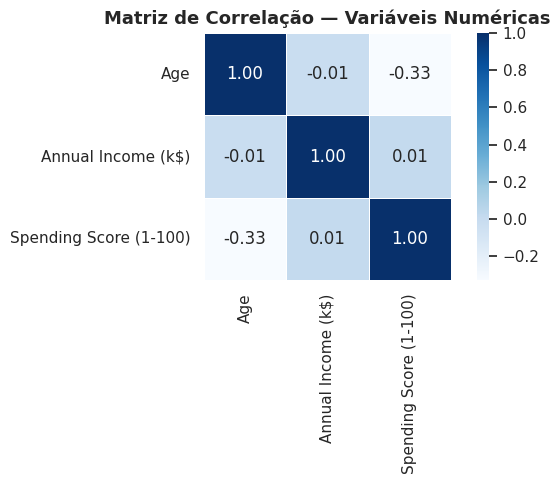

In [ ]:
# ----- Mapa de correlação -----
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[variaveis_numericas].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Age × Spending Score = −0,33**

Conforme a idade aumenta, o score de gastos tende a diminuir.
Na prática: clientes mais jovens gastam mais no shopping. Clientes mais velhos são mais contidos.
É uma correlação fraca-moderada — existe uma tendência, mas não é uma regra.

**Age × Annual Income = −0,01**

Praticamente zero. Pode ignorar — não há relação entre idade e renda nessa base.

In [ ]:
import pandas as pd
# ----- Storytelling de dados: insight de negócio -----
variaveis_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[variaveis_numericas].corr()
print('=== RESUMO EXECUTIVO — INSIGHTS DE NEGÓCIO ===')
print(f'Total de clientes: {len(df)}')
print(f'Idade média: {df["Age"].mean():.1f} anos (mediana: {df["Age"].median():.0f})')
print(f'Renda anual média: ${df["Annual Income (k$)"].mean():.1f}k')
print(f'Score de gastos médio: {df["Spending Score (1-100)"].mean():.1f}/100')
print(f'Correlação renda × score de gastos: {corr.loc["Annual Income (k$)","Spending Score (1-100)"]:.2f}')
print('\n→ A correlação fraca entre renda e score sugere que COMPORTAMENTO', end='')
print(' não é explicado apenas por renda — há outros fatores.')
print('→ Isso motiva a segmentação na Aula 3 (K-Means).')

=== RESUMO EXECUTIVO — INSIGHTS DE NEGÓCIO ===
Total de clientes: 200
Idade média: 38.9 anos (mediana: 36)
Renda anual média: $60.6k
Score de gastos médio: 50.2/100
Correlação renda × score de gastos: 0.01

→ A correlação fraca entre renda e score sugere que COMPORTAMENTO não é explicado apenas por renda — há outros fatores.
→ Isso motiva a segmentação na Aula 3 (K-Means).


**Célula 6 — Tratamento dos outliers**

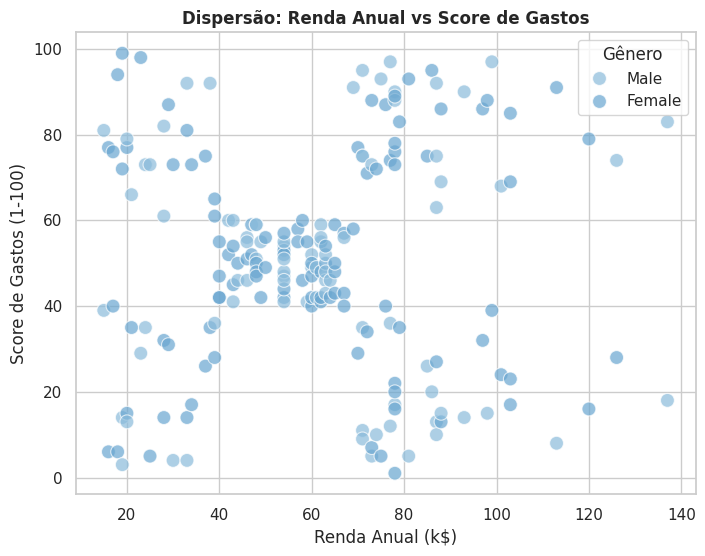

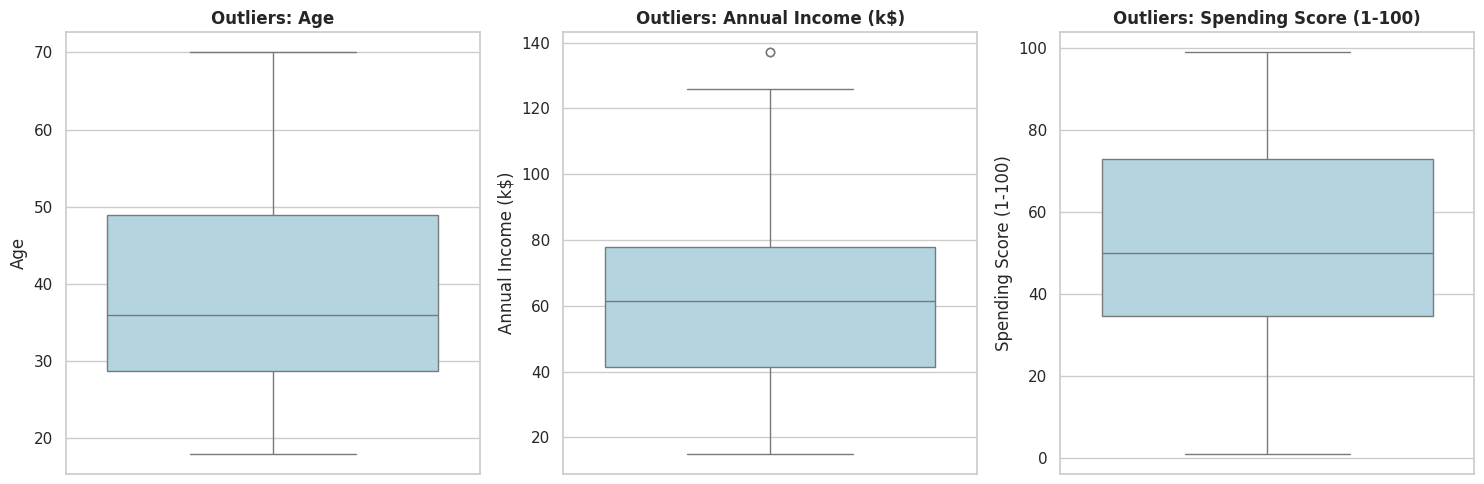

In [ ]:
# 1. Visualizando a (não) relação entre Renda e Gastos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Genre', s=100, alpha=0.7)
plt.title('Dispersão: Renda Anual vs Score de Gastos', fontweight='bold')
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Score de Gastos (1-100)')
plt.legend(title='Gênero')
plt.show()

# 2. Identificação de Outliers via Boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(variaveis_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Outliers: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

Note que na variável `Annual Income`, há um ponto isolado próximo de 140k. Esse outlier deve ser mantido ou removido?

Existe uma fórmula matemática (critério técnico) em decidir se um outlier deve ser removido ou mantido, ele se chama **Intervalo Interquartil (IQR)**



**Célula 7 - Calculando o IQR**

In [ ]:
# ----- Identificação Estatística de Outliers (Método IQR) -----
Q1 = df['Annual Income (k$)'].quantile(0.25)
Q3 = df['Annual Income (k$)'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
print(f'Limite Superior Estatístico: {limite_superior}k')

# Localizando os outliers
outliers = df[df['Annual Income (k$)'] > limite_superior]
print(f'\nClientes identificados como outliers:')
display(outliers)

# Comparação de impacto
media_com = df['Annual Income (k$)'].mean()
media_sem = df[df['Annual Income (k$)'] <= limite_superior]['Annual Income (k$)'].mean()

print(f'\n--- IMPACTO NA MÉDIA ---')
print(f'Média com outliers: {media_com:.2f}k')
print(f'Média sem outliers: {media_sem:.2f}k')
print(f'Diferença: {media_com - media_sem:.2f}k')

Limite Superior Estatístico: 132.75k

Clientes identificados como outliers:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83



--- IMPACTO NA MÉDIA ---
Média com outliers: 60.56k
Média sem outliers: 59.79k
Diferença: 0.77k


**Célula 8 - Vamos visualizar como é fica a renda média com e sem os outliers**

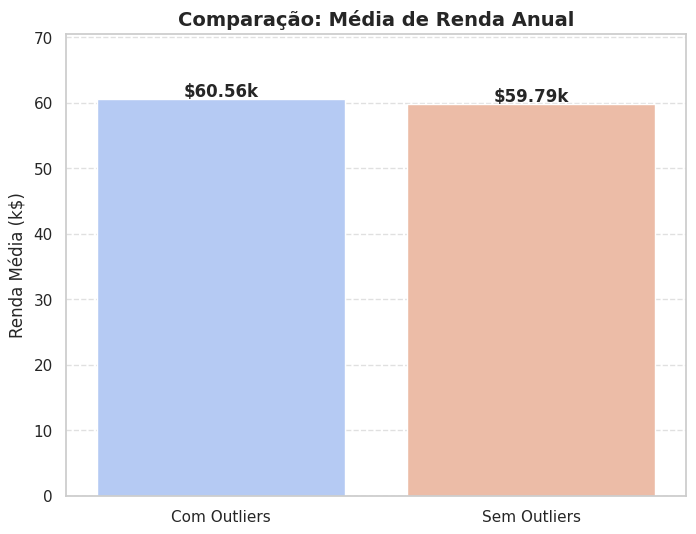

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados para o gráfico
labels = ['Com Outliers', 'Sem Outliers']
valores = [media_com, media_sem]

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=labels, y=valores, palette='coolwarm', hue=labels, legend=False)

# Adicionando rótulos de dados nas barras
for i, v in enumerate(valores):
    ax.text(i, v + 0.5, f'${v:.2f}k', ha='center', fontweight='bold')

plt.title('Comparação: Média de Renda Anual', fontsize=14, fontweight='bold')
plt.ylabel('Renda Média (k$)')
plt.ylim(0, max(valores) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Para debate se tiramos ou não:**

1.  **Impacto:** A remoção dos 2 outliers reduziu a média em quase $0.8k.
2.  **Decisão:** Em Analytics, se o objetivo é criar um modelo de recomendação para clientes *comuns*, removemos. Se o objetivo é entender o mercado de *luxo/alto padrão*, esses outliers são nossos clientes mais valiosos e devem ser estudados à parte.

**Célula 9 - Criando um dataset sem outliers**

Tamanho original: 200 linhas
Tamanho após limpeza: 198 linhas
Linhas removidas: 2


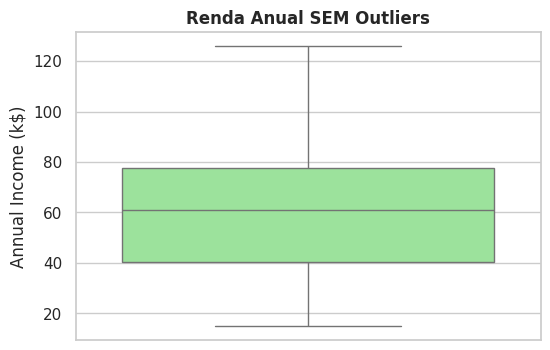

In [ ]:
# ----- Criando o dataset limpo (sem outliers) -----
df_cleaned = df[df['Annual Income (k$)'] <= limite_superior]

# Verificação
print(f'Tamanho original: {len(df)} linhas')
print(f'Tamanho após limpeza: {len(df_cleaned)} linhas')
print(f'Linhas removidas: {len(df) - len(df_cleaned)}')

# Visualizando o novo Boxplot para confirmar a limpeza
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_cleaned['Annual Income (k$)'], color='lightgreen')
plt.title('Renda Anual SEM Outliers', fontweight='bold')
plt.show()

**Célula 10 - Exportando um dataset sem outliers**

In [ ]:
# Salvando o dataframe limpo em um arquivo CSV
df_cleaned.to_csv('mall_customers_cleaned.csv', index=False)

print('Sucesso! O arquivo "mall_customers_cleaned.csv" foi gerado.')

Sucesso! O arquivo "mall_customers_cleaned.csv" foi gerado.
